In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

In [39]:
data = pd.read_csv("results-CA-2024-12-29 11:33:55.119418.csv")

vars = data[["params_depth", "params_grid", "params_k"]]
values = data["value"]
data.shape

(20, 13)

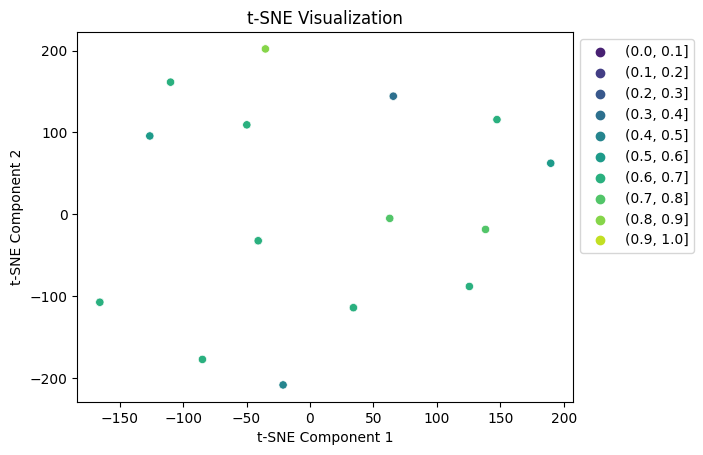

In [43]:
# Perform t-SNE
vis = TSNE(n_components=2, random_state=42, perplexity=10, learning_rate=2)
# vis = PCA(n_components=2)
# vis = UMAP(n_components=2)

results = vis.fit_transform(vars)

# Create a DataFrame for the t-SNE results
df = pd.DataFrame(results, columns=["TSNE1", "TSNE2"])
df["value"] = values

bins = np.linspace(0, 1, 11)
# Create bins and categorize the "value" column
df["value_bins"] = pd.cut(df["value"], bins=bins, include_lowest=False)


# Plotting the t-SNE results
# plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df, x="TSNE1", y="TSNE2", hue="value_bins", palette="viridis", legend="full"
)
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(bbox_to_anchor=(1, 1))